# Assignment 6

<font size = "5">

Import the "pandas" and "matplotlib.pyplot" libraries (and any other libraries if you would like)

In [ ]:
# Import libraries

import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt 


<font size = "5">

(a) Functions

<font size = "3">

- Read in the dataset named "features.csv".
- Create a ``` lambda ``` function that checks if weight $≤$ 3000
- Using the Pandas method ``.apply()``, create a new Series that shows ``True`` if weight $≤$ 3000 and ``False``if weight > 3000.
- Using the ``.shape`` attribute, print the number of cars that have weight $≤$ 3000.

**Hint**: A Pandas Series has only one dimension, so the ``.shape`` attribute is a "tuple" with only one element. In order to get a single integer, type ``your_variable_name.shape[0]``


In [9]:
# Write your answer here:

features_data = pd.read_csv("data/features.csv")

weight_check = lambda weight: weight <= 3000

series_weight_check = features_data["weight"].apply(weight_check)
print(series_weight_check[series_weight_check].shape[0])  

230


<font size = "5">

(b) Subsetting Data

<font size = "3" >

- Read in the dataset named "features.csv".
- Define a global variable called ```threshold``` that takes the <br>
value 2500
- Subset the data to get one dataset with weight $>$ threshold and <br>
another with weight $\le$ threshold. Use the ```.query()``` function.
- Compute the mean acceleration for each of these datasets, printing these values to the screen<br>

Note: Review how to define a global variable inside ```.query()```
 

In [ ]:
# Write your answer here:
threshold = 2500

weight_larger_than_threshold = features_data.query( "weight > @threshold" )
weight_less_than_equal_to_threshold = features_data.query( "weight <= @threshold" )

mean_acc_larger = weight_larger_than_threshold["acceleration"].mean()
mean_acc_lessthan = weight_less_than_equal_to_threshold["acceleration"].mean()

print(f"Mean acceleration (weight >  {threshold}): {mean_acc_larger:.2f}")
print(f"Mean acceleration (weight <= {threshold}): {mean_acc_lessthan:.2f}")

n (weight >  2500): 251
n (weight <= 2500): 147
Mean acceleration (weight >  2500): 15.00
Mean acceleration (weight <= 2500): 16.54


<font size = "5">

(c) Use sorting + ".iloc[]"

<font size = "3">

- Read the "fifa23_players_basic.csv" dataset
- Use ".sort_values()" to order the "Age" column <br>
from oldest to youngest
- Get a subset with the 5 oldest players

In [ ]:
# Write your answer here:

df_fifa = pd.read_csv("data/fifa23_players_basic.csv")
df_fifa_sorted = df_fifa.sort_values(by = "Age", ascending = False)
df_fifa_sorted = df_fifa_sorted.reset_index(drop = True)

oldest_five = df_fifa_sorted.iloc[:5, :]
print(oldest_five)


      Known As          Full Name  Overall  Potential  Value(in Euro)  \
0    G. Buffon   Gianluigi Buffon       79         79         1900000   
1     S. Lukić       Stojan Lukić       62         62           45000   
2   S. Torrico  Sebastián Torrico       72         72          250000   
3  J. Szmatuła     Jakub Szmatuła       59         59           25000   
4    M. Galezo      Moisés Galezo       64         64               0   

  Positions Played Best Position             Nationality  \
0               GK            GK                   Italy   
1               GK            GK  Bosnia and Herzegovina   
2               GK            GK               Argentina   
3               GK            GK                  Poland   
4               CB            CB               Venezuela   

                                         Image Link  Age  ...  Preferred Foot  \
0  https://cdn.sofifa.net/players/001/179/23_60.png   44  ...           Right   
1  https://cdn.sofifa.net/players/213/

<font size = "5">

(d) Use queries + global variables

<font size = "3">

- Read the "fifa23_players_basic.csv" dataset
- Compute the mean of the column "Weight(in kg)"
and store it as a variable
- Subset the players whose Weight in kilograms is stricly large than this mean value
  using ".query()"


HINT: Remember that there is a special syntax for when using column names inside the .query() method (the backtick `)

In [17]:
# Write your answer here:

avg_weight = df_fifa["Weight(in kg)"].mean()
weight_above_avg = df_fifa.query( "`Weight(in kg)` > @avg_weight" )


<font size = "5">

(e) Plot by Category

<font size = "3">

Read in the dataset named "wdi_urban.csv".

  This contains data from 1980 and 2020.

- **Create an array with the unique values of "year" using the ``Pandas`` function ``unique``**

- **Create a plot with a ...**
    - Histogram of "prop_urbanpopulation" (proportion of urban population) for each year
    - Set the histogram option `alpha = 0.5` for transparency
    - All the histograms should be overlapping on the same plot
    - Create a legend with the list of years
    - Label the axes and the title

**Hint**: The procedure will be similar (but not exactly the same!) as when we created a scatter plot of cars with different numbers of cylinders in Lecture 11

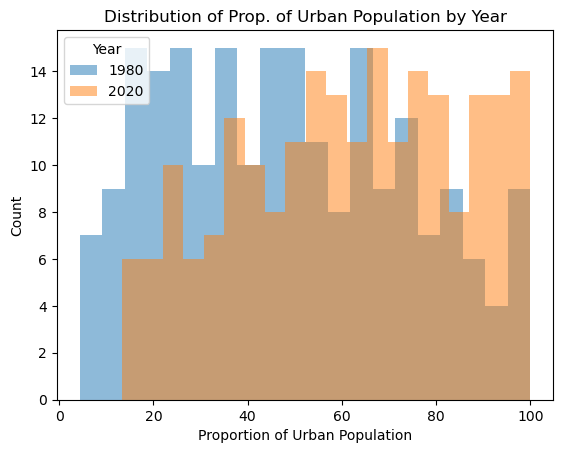

In [ ]:
# your answer here
df_urban = pd.read_csv("data/wdi_urban.csv")
array_unique_years = pd.unique(df_urban["year"])
             
for yr in array_unique_years:
    df = df_urban.query("year == @yr")["prop_urbanpopulation"].dropna()
    plt.hist(df, bins = 20, alpha=0.5, label=str(yr))

plt.xlabel("Proportion of Urban Population")
plt.ylabel("Count")
plt.title("Distribution of Prop. of Urban Population by Year")
plt.legend(title= "Year")
plt.show()